# 06b - Extended Analysis: LSTM (Google Colab)

This notebook extends the analysis from notebook 06 by applying LSTM models to:
1. **Regional Analysis** - LSTM predictions across 5 PADD regions
2. **Geopolitical Event Analysis** - LSTM robustness to price shocks from major world events
3. **Concept Drift** - Training on historical data and testing on unseen future periods

**Environment:** Google Colab with PyTorch

## Setup

### Upload Data Files

Upload the following files when prompted:
- `padd1_east_coast.xls`
- `padd2_midwest.xls`
- `padd3_gulf_coast.xls`
- `padd4_rocky_mountain.xls`
- `padd5_west_coast.xls`
- `national_allgrades_updated.xls`
- `PET_PRI_GND_DCUS_NUS_W.csv`

In [1]:
from google.colab import files

# Upload 1: Original national CSV (from data/raw/)
print("=" * 50)
print("UPLOAD 1/3: Select PET_PRI_GND_DCUS_NUS_W.csv")
print("(from data/raw/)")
print("=" * 50)
uploaded1 = files.upload()
print(f"Got: {list(uploaded1.keys())}\n")

# Upload 2: Regional XLS files (from data/raw/regional/)
print("=" * 50)
print("UPLOAD 2/3: Select ALL 5 regional files at once")
print("(from data/raw/regional/ — hold Cmd to multi-select)")
print("  padd1_east_coast.xls")
print("  padd2_midwest.xls")
print("  padd3_gulf_coast.xls")
print("  padd4_rocky_mountain.xls")
print("  padd5_west_coast.xls")
print("=" * 50)
uploaded2 = files.upload()
print(f"Got: {list(uploaded2.keys())}\n")

# Upload 3: Updated national XLS (from data/raw/national_updated/)
print("=" * 50)
print("UPLOAD 3/3: Select national_allgrades_updated.xls")
print("(from data/raw/national_updated/)")
print("=" * 50)
uploaded3 = files.upload()
print(f"Got: {list(uploaded3.keys())}\n")

all_uploaded = {**uploaded1, **uploaded2, **uploaded3}
print(f"\nTotal: {len(all_uploaded)} files uploaded: {sorted(all_uploaded.keys())}")

UPLOAD 1/3: Select PET_PRI_GND_DCUS_NUS_W.csv
(from data/raw/)


Saving PET_PRI_GND_DCUS_NUS_W.csv to PET_PRI_GND_DCUS_NUS_W.csv
Got: ['PET_PRI_GND_DCUS_NUS_W.csv']

UPLOAD 2/3: Select ALL 5 regional files at once
(from data/raw/regional/ — hold Cmd to multi-select)
  padd1_east_coast.xls
  padd2_midwest.xls
  padd3_gulf_coast.xls
  padd4_rocky_mountain.xls
  padd5_west_coast.xls


Saving padd1_east_coast.xls to padd1_east_coast.xls
Saving padd2_midwest.xls to padd2_midwest.xls
Saving padd3_gulf_coast.xls to padd3_gulf_coast.xls
Saving padd4_rocky_mountain.xls to padd4_rocky_mountain.xls
Saving padd5_west_coast.xls to padd5_west_coast.xls
Got: ['padd1_east_coast.xls', 'padd2_midwest.xls', 'padd3_gulf_coast.xls', 'padd4_rocky_mountain.xls', 'padd5_west_coast.xls']

UPLOAD 3/3: Select national_allgrades_updated.xls
(from data/raw/national_updated/)


Saving national_allgrades_updated.xls to national_allgrades_updated.xls
Saving national_regular_updated.xls to national_regular_updated.xls
Got: ['national_allgrades_updated.xls', 'national_regular_updated.xls']


Total: 8 files uploaded: ['PET_PRI_GND_DCUS_NUS_W.csv', 'national_allgrades_updated.xls', 'national_regular_updated.xls', 'padd1_east_coast.xls', 'padd2_midwest.xls', 'padd3_gulf_coast.xls', 'padd4_rocky_mountain.xls', 'padd5_west_coast.xls']


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xlrd
import json
import copy
import os

# Device detection
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

Using device: cuda


### Utility Functions

In [3]:
# --- Data Loading ---

def load_xls_data(filename):
    """Load weekly price data from an EIA XLS file."""
    wb = xlrd.open_workbook(filename)
    ws = wb.sheet_by_name('Data 1')
    dates, prices = [], []
    for i in range(3, ws.nrows):
        dates.append(xlrd.xldate_as_datetime(ws.cell_value(i, 0), wb.datemode))
        prices.append(ws.cell_value(i, 1))
    df = pd.DataFrame({'Date': dates, 'Price': prices})
    df['Date'] = pd.to_datetime(df['Date'])
    return df.sort_values('Date').reset_index(drop=True)

In [4]:
# --- Feature Engineering ---

def add_features_single(df, price_col='Price', lags=None, rolling_windows=None):
    """Add lag, rolling, diff, pct_change, and date features for a single price column."""
    if lags is None:
        lags = [1, 2, 3, 4, 8, 12]
    if rolling_windows is None:
        rolling_windows = [4, 8, 12]

    df = df.copy()

    # Lag features
    for lag in lags:
        df[f'lag{lag}'] = df[price_col].shift(lag)

    # Rolling statistics (shifted by 1 to avoid leakage)
    for w in rolling_windows:
        df[f'rolling_mean_{w}'] = df[price_col].shift(1).rolling(w).mean()
        df[f'rolling_std_{w}'] = df[price_col].shift(1).rolling(w).std()

    # Differencing
    df['diff_1'] = df[price_col].diff(1)
    df['diff_4'] = df[price_col].diff(4)

    # Percentage change
    df['pct_change_1'] = df[price_col].pct_change(1)
    df['pct_change_4'] = df[price_col].pct_change(4)

    # Date features
    df['month'] = df['Date'].dt.month
    df['quarter'] = df['Date'].dt.quarter
    df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    return df

In [5]:
# --- Target Creation and Splitting ---

def create_target(df, price_col='Price', horizon=1):
    """Create target column as future price shifted by horizon."""
    df = df.copy()
    df['target'] = df[price_col].shift(-horizon)
    return df


def train_val_test_split(df, train_ratio=0.7, val_ratio=0.15):
    """Chronological train/val/test split (70/15/15)."""
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train = df.iloc[:train_end].copy()
    val = df.iloc[train_end:val_end].copy()
    test = df.iloc[val_end:].copy()

    return train, val, test

In [6]:
# --- Evaluation ---

def evaluate_model(y_true, y_pred):
    """Compute RMSE, MAE, and MAPE."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return {'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'MAPE': round(mape, 4)}


def save_results(results, filename):
    """Save results dictionary to JSON."""
    with open(filename, 'w') as f:
        json.dump(results, f, indent=2)
    print(f'Results saved to {filename}')

In [7]:
# --- LSTM Sequence Utilities ---

def create_sequences(X, y, seq_len):
    """Create sequences of length seq_len for LSTM input."""
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len + 1):
        X_seq.append(X[i:i + seq_len])
        y_seq.append(y[i + seq_len - 1])
    return np.array(X_seq), np.array(y_seq)


def prepare_seq_data_single(train_X, train_y, val_X, val_y, test_X, test_y,
                            seq_len=12, batch_size=32):
    """Scale features, create sequences, and build DataLoaders."""
    scaler = StandardScaler()
    train_X_sc = scaler.fit_transform(train_X)
    val_X_sc = scaler.transform(val_X)
    test_X_sc = scaler.transform(test_X)

    train_X_seq, train_y_seq = create_sequences(train_X_sc, train_y, seq_len)
    val_X_seq, val_y_seq = create_sequences(val_X_sc, val_y, seq_len)
    test_X_seq, test_y_seq = create_sequences(test_X_sc, test_y, seq_len)

    train_ds = TensorDataset(
        torch.FloatTensor(train_X_seq),
        torch.FloatTensor(train_y_seq)
    )
    val_ds = TensorDataset(
        torch.FloatTensor(val_X_seq),
        torch.FloatTensor(val_y_seq)
    )
    test_ds = TensorDataset(
        torch.FloatTensor(test_X_seq),
        torch.FloatTensor(test_y_seq)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, scaler, test_y_seq

In [8]:
# --- LSTM Model ---

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out.squeeze(-1)

In [9]:
# --- LSTM Training ---

def train_seq_model(model, train_loader, val_loader, epochs=200, lr=1e-3,
                    patience=20, device='cpu'):
    """Train LSTM model with early stopping, LR scheduling, and gradient clipping."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=7
    )
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # Training
        model.train()
        epoch_train_loss = 0.0
        n_train = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_train_loss += loss.item() * len(y_batch)
            n_train += len(y_batch)
        epoch_train_loss /= n_train
        train_losses.append(epoch_train_loss)

        # Validation
        model.eval()
        epoch_val_loss = 0.0
        n_val = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                loss = criterion(pred, y_batch)
                epoch_val_loss += loss.item() * len(y_batch)
                n_val += len(y_batch)
        epoch_val_loss /= n_val
        val_losses.append(epoch_val_loss)

        scheduler.step(epoch_val_loss)

        # Early stopping
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 20 == 0:
            print(f'Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.6f} - Val Loss: {epoch_val_loss:.6f}')

        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, train_losses, val_losses


def predict_seq_model(model, data_loader, device='cpu'):
    """Generate predictions from a trained LSTM model."""
    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch, _ in data_loader:
            X_batch = X_batch.to(device)
            pred = model(X_batch)
            preds.append(pred.cpu().numpy())
    return np.concatenate(preds)

---

## Part 1: Regional LSTM Analysis

Train and evaluate LSTM models on each of the 5 PADD regions.

In [10]:
# Regional file mapping
regional_files = {
    'PADD1_East_Coast': 'padd1_east_coast.xls',
    'PADD2_Midwest': 'padd2_midwest.xls',
    'PADD3_Gulf_Coast': 'padd3_gulf_coast.xls',
    'PADD4_Rocky_Mountain': 'padd4_rocky_mountain.xls',
    'PADD5_West_Coast': 'padd5_west_coast.xls'
}

# Load all regional data
regional_data = {}
for region, fname in regional_files.items():
    df = load_xls_data(fname)
    print(f'{region}: {len(df)} rows, {df["Date"].min().date()} to {df["Date"].max().date()}')
    regional_data[region] = df

PADD1_East_Coast: 1770 rows, 1992-05-11 to 2026-04-06
PADD2_Midwest: 1770 rows, 1992-05-11 to 2026-04-06
PADD3_Gulf_Coast: 1770 rows, 1992-05-11 to 2026-04-06
PADD4_Rocky_Mountain: 1770 rows, 1992-05-11 to 2026-04-06
PADD5_West_Coast: 1770 rows, 1992-05-11 to 2026-04-06


In [11]:
# LSTM hyperparameters
SEQ_LEN = 12
BATCH_SIZE = 32
HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.2
EPOCHS = 200
PATIENCE = 20
LR = 1e-3

In [12]:
# Train LSTM for each region
regional_results = {}
regional_predictions = {}

for region, df_raw in regional_data.items():
    print(f'\n{"="*60}')
    print(f'Training LSTM for {region}')
    print(f'{"="*60}')

    # Feature engineering
    df = add_features_single(df_raw)
    df = create_target(df)
    df = df.dropna().reset_index(drop=True)

    # Split
    train_df, val_df, test_df = train_val_test_split(df)
    print(f'Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}')

    # Prepare features and targets
    feature_cols = [c for c in df.columns if c not in ['Date', 'Price', 'target']]
    train_X = train_df[feature_cols].values
    train_y = train_df['target'].values
    val_X = val_df[feature_cols].values
    val_y = val_df['target'].values
    test_X = test_df[feature_cols].values
    test_y = test_df['target'].values

    # Prepare sequences
    train_loader, val_loader, test_loader, scaler, test_y_seq = prepare_seq_data_single(
        train_X, train_y, val_X, val_y, test_X, test_y,
        seq_len=SEQ_LEN, batch_size=BATCH_SIZE
    )

    # Build and train model
    torch.manual_seed(SEED)
    n_features = train_X.shape[1]
    model = LSTMModel(
        input_size=n_features,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT
    )

    model, train_losses, val_losses = train_seq_model(
        model, train_loader, val_loader,
        epochs=EPOCHS, lr=LR, patience=PATIENCE, device=device
    )

    # Predict and evaluate
    test_preds = predict_seq_model(model, test_loader, device=device)
    metrics = evaluate_model(test_y_seq, test_preds)
    print(f'\n{region} Test Metrics: {metrics}')

    regional_results[region] = metrics
    regional_predictions[region] = {
        'actual': test_y_seq,
        'predicted': test_preds,
        'dates': test_df['Date'].values[SEQ_LEN - 1:]
    }

    # Save individual results
    save_results(
        {region: metrics},
        f'lstm_regional_{region.lower()}.json'
    )


Training LSTM for PADD1_East_Coast
Train: 1229, Val: 264, Test: 264
Epoch 20/200 - Train Loss: 0.030410 - Val Loss: 0.003311
Epoch 40/200 - Train Loss: 0.023301 - Val Loss: 0.003237
Epoch 60/200 - Train Loss: 0.021061 - Val Loss: 0.002500
Epoch 80/200 - Train Loss: 0.022682 - Val Loss: 0.001938
Epoch 100/200 - Train Loss: 0.019981 - Val Loss: 0.001943
Early stopping at epoch 100

PADD1_East_Coast Test Metrics: {'RMSE': np.float64(0.1024), 'MAE': np.float64(0.0596), 'MAPE': np.float64(1.6673)}
Results saved to lstm_regional_padd1_east_coast.json

Training LSTM for PADD2_Midwest
Train: 1229, Val: 264, Test: 264
Epoch 20/200 - Train Loss: 0.031959 - Val Loss: 0.005608
Epoch 40/200 - Train Loss: 0.026741 - Val Loss: 0.004495
Epoch 60/200 - Train Loss: 0.023083 - Val Loss: 0.004514
Epoch 80/200 - Train Loss: 0.022982 - Val Loss: 0.003970
Epoch 100/200 - Train Loss: 0.020638 - Val Loss: 0.004042
Early stopping at epoch 105

PADD2_Midwest Test Metrics: {'RMSE': np.float64(0.1178), 'MAE': np.

### Regional Comparison Table

In [13]:
# Create comparison table
results_df = pd.DataFrame(regional_results).T
results_df.index.name = 'Region'
print('\nLSTM Regional Comparison:')
print('=' * 60)
print(results_df.to_string())

# Save combined results
save_results(regional_results, 'lstm_regional_comparison.json')


LSTM Regional Comparison:
                        RMSE     MAE    MAPE
Region                                      
PADD1_East_Coast      0.1024  0.0596  1.6673
PADD2_Midwest         0.1178  0.0754  2.1718
PADD3_Gulf_Coast      0.1200  0.0815  2.5678
PADD4_Rocky_Mountain  0.1380  0.0862  2.3414
PADD5_West_Coast      0.2741  0.1783  3.6769
Results saved to lstm_regional_comparison.json


### Regional Prediction Plots

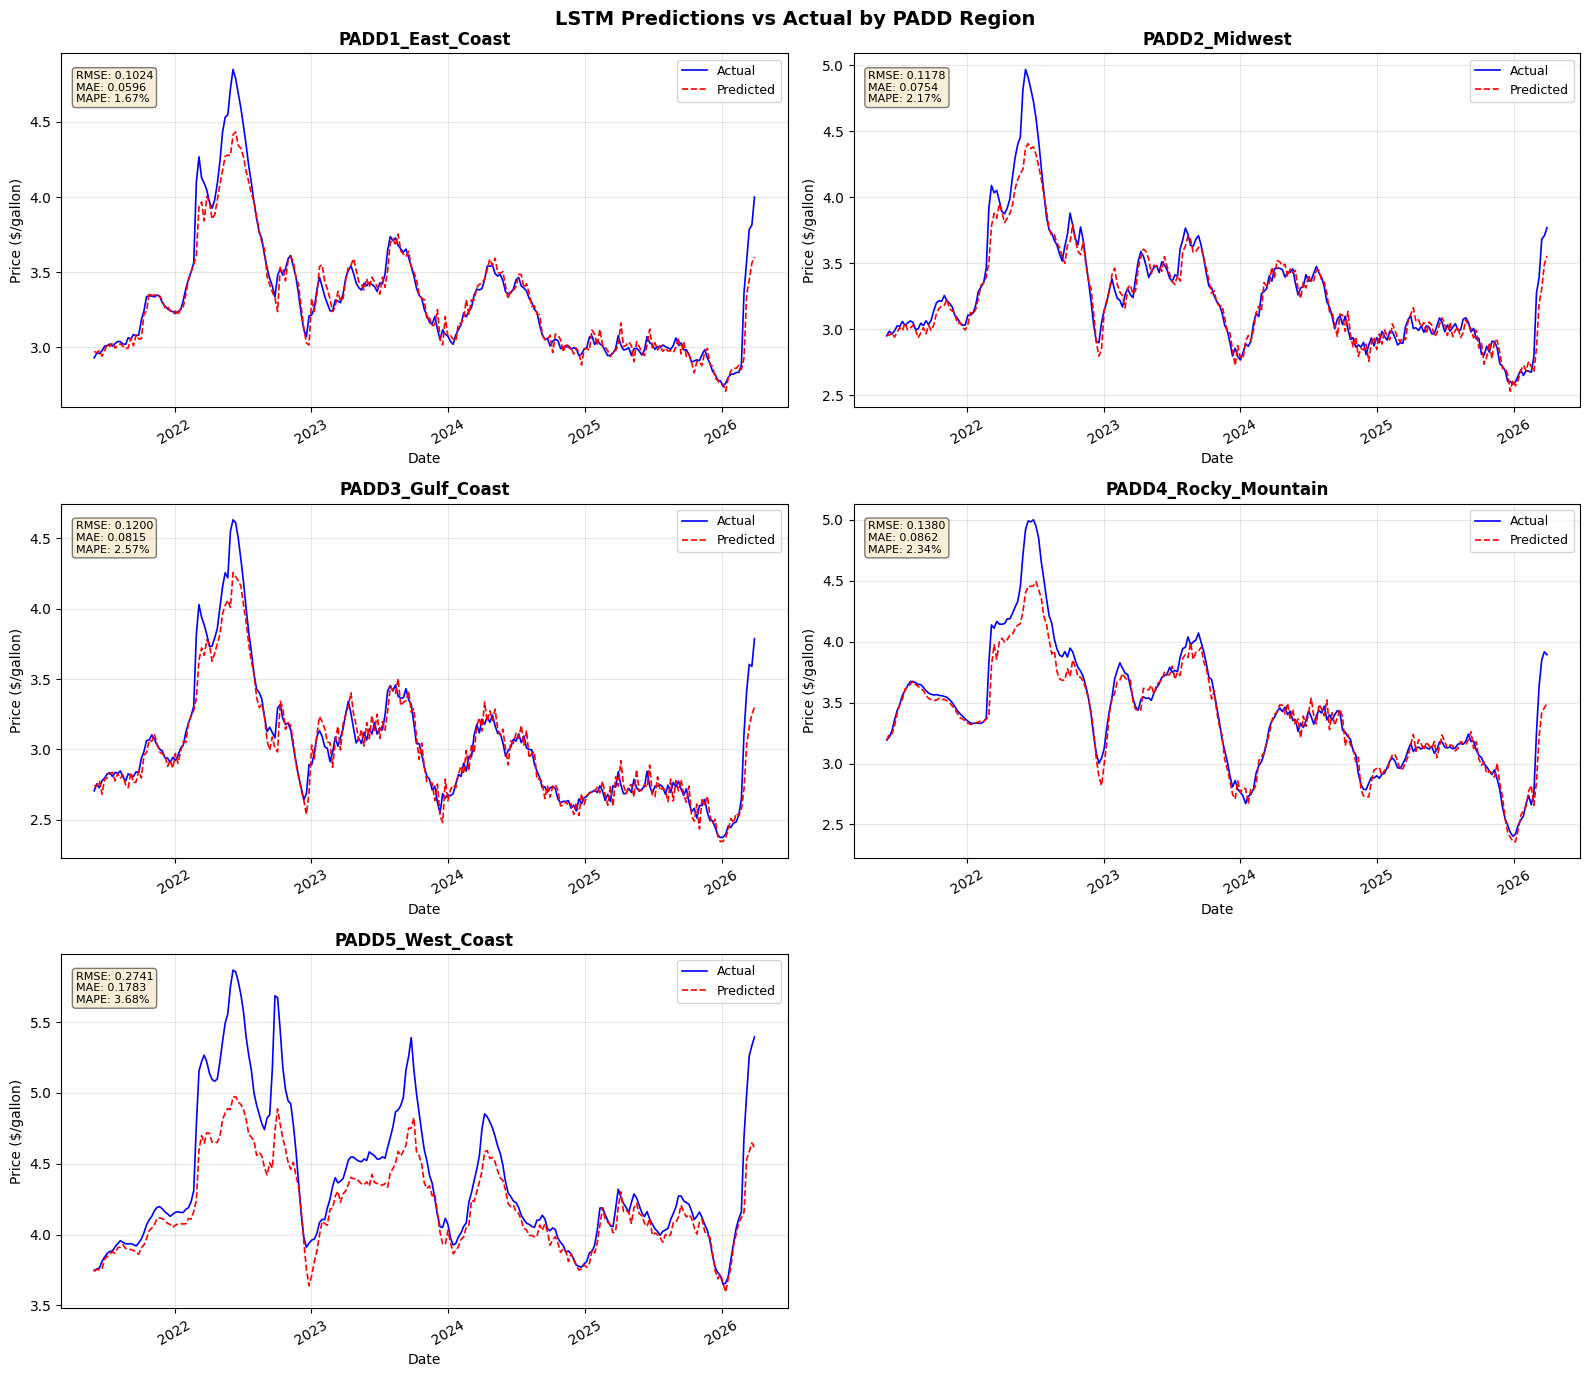

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (region, pred_data) in enumerate(regional_predictions.items()):
    ax = axes[idx]
    dates = pd.to_datetime(pred_data['dates'])
    ax.plot(dates, pred_data['actual'], label='Actual', color='blue', linewidth=1.2)
    ax.plot(dates, pred_data['predicted'], label='Predicted', color='red',
            linewidth=1.2, linestyle='--')
    ax.set_title(f'{region}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($/gallon)')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3)

    # Add metrics text
    metrics = regional_results[region]
    ax.text(0.02, 0.95,
            f"RMSE: {metrics['RMSE']:.4f}\nMAE: {metrics['MAE']:.4f}\nMAPE: {metrics['MAPE']:.2f}%",
            transform=ax.transAxes, fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle('LSTM Predictions vs Actual by PADD Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_regional_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Part 2: Geopolitical Event & Outlier Analysis

We define 4 major events that caused gasoline price shocks. For each event, we train an LSTM on data **before** the event and test predictions **during** the event period. This reveals how robust neural networks are to sudden, unprecedented price movements.

Events:
- **Hurricane Katrina** (Aug–Oct 2005): Gulf Coast supply disruption
- **2008 Financial Crisis** (Jul 2008–Mar 2009): demand collapse
- **2014–16 Oil Price Crash** (Jun 2014–Feb 2016): OPEC oversupply
- **COVID-19 Pandemic** (Mar–Jun 2020): demand collapse

In [15]:
# Define geopolitical events
events = {
    'Hurricane Katrina': ('2005-08-01', '2005-10-31'),
    '2008 Financial Crisis': ('2008-07-01', '2009-03-31'),
    '2014-16 Oil Price Crash': ('2014-06-01', '2016-02-29'),
    'COVID-19 Pandemic': ('2020-03-01', '2020-06-30'),
}

event_colors = {
    'Hurricane Katrina': '#ff6b6b',
    '2008 Financial Crisis': '#ffa07a',
    '2014-16 Oil Price Crash': '#98d8c8',
    'COVID-19 Pandemic': '#c3a6ff',
}

for name, (start, end) in events.items():
    print(f"{name}: {start} to {end}")

Hurricane Katrina: 2005-08-01 to 2005-10-31
2008 Financial Crisis: 2008-07-01 to 2009-03-31
2014-16 Oil Price Crash: 2014-06-01 to 2016-02-29
COVID-19 Pandemic: 2020-03-01 to 2020-06-30


### Outlier Detection

Use IQR and Z-score methods to identify outlier weeks in price changes, then show that outliers cluster around geopolitical events.

In [16]:
# Load national data for outlier analysis
# Use the original CSV which covers 1995-2021 (contains all 4 events)
nat_df = pd.read_csv('PET_PRI_GND_DCUS_NUS_W.csv')
nat_df['Date'] = pd.to_datetime(nat_df['Date'], format='%m/%d/%Y')
nat_df = nat_df[['Date', 'A1']].rename(columns={'A1': 'Price'})
nat_df['Price'] = pd.to_numeric(nat_df['Price'], errors='coerce')
nat_df = nat_df.dropna(subset=['Price']).sort_values('Date').reset_index(drop=True)

# Compute weekly changes
nat_df['weekly_change'] = nat_df['Price'].diff()
nat_df['pct_change'] = nat_df['Price'].pct_change() * 100
nat_df = nat_df.dropna(subset=['weekly_change']).reset_index(drop=True)

# --- IQR Method ---
Q1 = nat_df['weekly_change'].quantile(0.25)
Q3 = nat_df['weekly_change'].quantile(0.75)
IQR = Q3 - Q1
iqr_lower = Q1 - 1.5 * IQR
iqr_upper = Q3 + 1.5 * IQR
nat_df['outlier_iqr'] = (nat_df['weekly_change'] < iqr_lower) | (nat_df['weekly_change'] > iqr_upper)

# --- Z-Score Method ---
mean_change = nat_df['weekly_change'].mean()
std_change = nat_df['weekly_change'].std()
nat_df['zscore'] = (nat_df['weekly_change'] - mean_change) / std_change
nat_df['outlier_zscore'] = nat_df['zscore'].abs() > 2.5

# Combined: outlier by either method
nat_df['outlier'] = nat_df['outlier_iqr'] | nat_df['outlier_zscore']

n_iqr = nat_df['outlier_iqr'].sum()
n_z = nat_df['outlier_zscore'].sum()
n_combined = nat_df['outlier'].sum()
print(f"IQR outliers: {n_iqr} ({n_iqr/len(nat_df)*100:.1f}%)")
print(f"Z-score outliers (|z| > 2.5): {n_z} ({n_z/len(nat_df)*100:.1f}%)")
print(f"Combined (union): {n_combined} ({n_combined/len(nat_df)*100:.1f}%)")
print(f"IQR bounds: [{iqr_lower:.4f}, {iqr_upper:.4f}] $/gallon per week")

IQR outliers: 107 (7.9%)
Z-score outliers (|z| > 2.5): 37 (2.7%)
Combined (union): 107 (7.9%)
IQR bounds: [-0.0794, 0.0816] $/gallon per week


In [17]:
# Outlier concentration by event period
event_outlier_counts = {}
for name, (start, end) in events.items():
    mask = (nat_df['Date'] >= pd.Timestamp(start)) & (nat_df['Date'] <= pd.Timestamp(end))
    total_weeks = mask.sum()
    outlier_weeks = (mask & nat_df['outlier']).sum()
    event_outlier_counts[name] = {
        'Total Weeks': int(total_weeks),
        'Outlier Weeks': int(outlier_weeks),
        'Outlier Rate (%)': round(outlier_weeks / total_weeks * 100, 1) if total_weeks > 0 else 0,
    }

# Normal periods
event_mask = pd.Series(False, index=nat_df.index)
for name, (start, end) in events.items():
    event_mask |= (nat_df['Date'] >= pd.Timestamp(start)) & (nat_df['Date'] <= pd.Timestamp(end))
normal_total = (~event_mask).sum()
normal_outliers = (~event_mask & nat_df['outlier']).sum()
event_outlier_counts['Normal Periods'] = {
    'Total Weeks': int(normal_total),
    'Outlier Weeks': int(normal_outliers),
    'Outlier Rate (%)': round(normal_outliers / normal_total * 100, 1),
}

outlier_table = pd.DataFrame(event_outlier_counts).T
print('Outlier Concentration by Event Period:')
print('=' * 55)
print(outlier_table.to_string())

Outlier Concentration by Event Period:
                         Total Weeks  Outlier Weeks  Outlier Rate (%)
Hurricane Katrina               14.0            8.0              57.1
2008 Financial Crisis           39.0           16.0              41.0
2014-16 Oil Price Crash         92.0           16.0              17.4
COVID-19 Pandemic               18.0            4.0              22.2
Normal Periods                1197.0           63.0               5.3


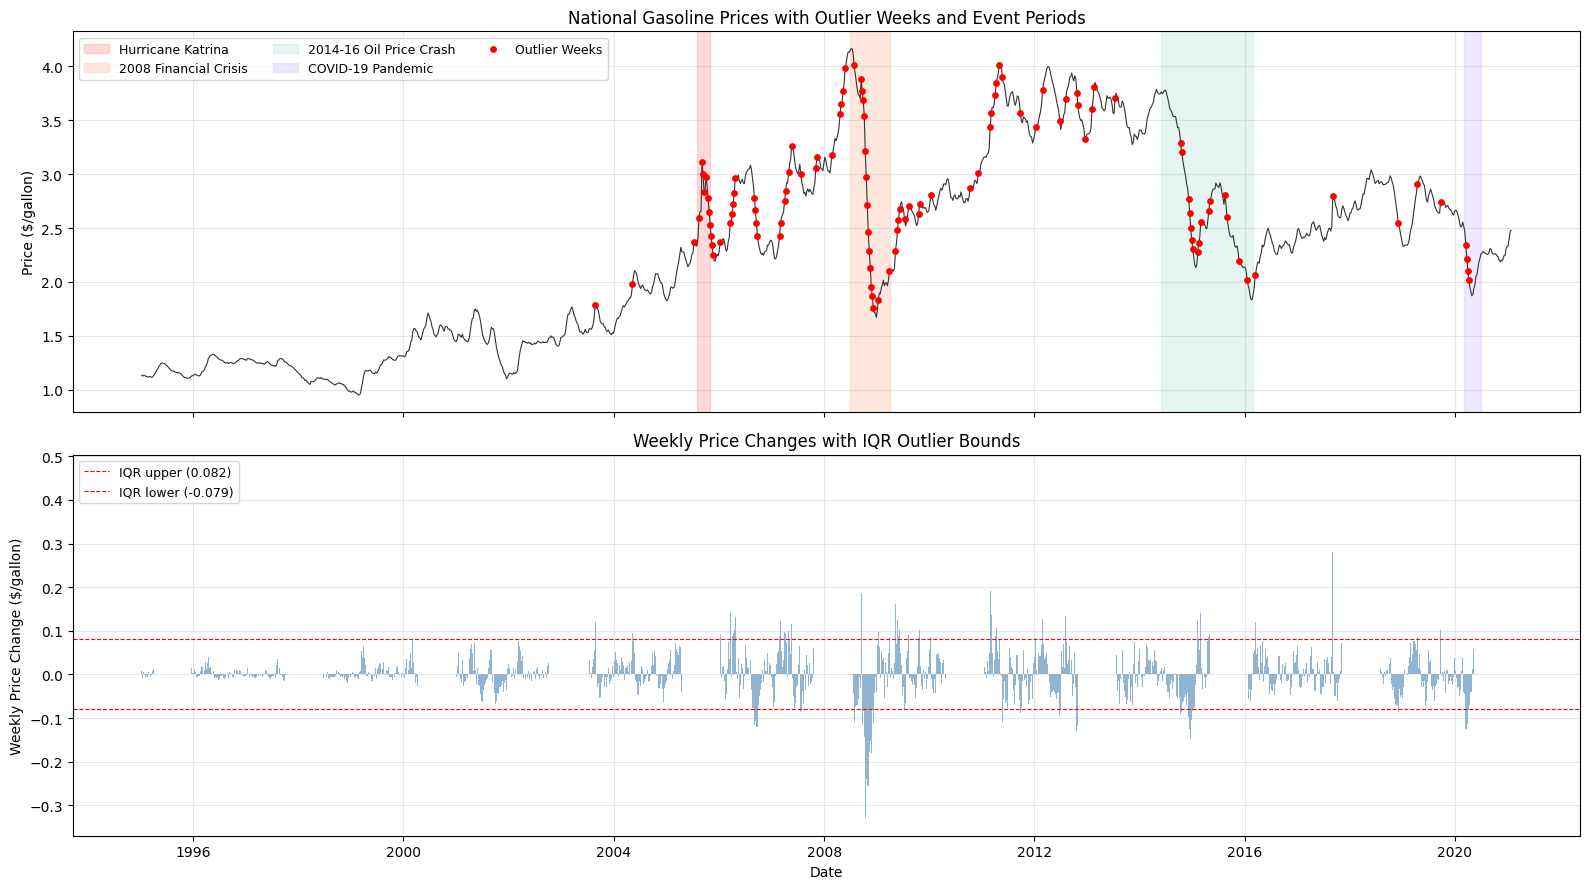

In [18]:
# Plot: Price series with event shading and outliers
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# Top: price with event shading
ax = axes[0]
ax.plot(nat_df['Date'], nat_df['Price'], linewidth=0.8, color='#333333')
for name, (start, end) in events.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               alpha=0.25, color=event_colors[name], label=name)
outlier_mask = nat_df['outlier']
ax.scatter(nat_df.loc[outlier_mask, 'Date'], nat_df.loc[outlier_mask, 'Price'],
           color='red', s=15, zorder=5, label='Outlier Weeks')
ax.set_ylabel('Price ($/gallon)')
ax.set_title('National Gasoline Prices with Outlier Weeks and Event Periods')
ax.legend(loc='upper left', fontsize=9, ncol=3)
ax.grid(True, alpha=0.3)

# Bottom: weekly changes with outlier threshold
ax = axes[1]
ax.bar(nat_df['Date'], nat_df['weekly_change'], width=5, color='steelblue', alpha=0.6)
ax.axhline(iqr_upper, color='red', linestyle='--', linewidth=0.8, label=f'IQR upper ({iqr_upper:.3f})')
ax.axhline(iqr_lower, color='red', linestyle='--', linewidth=0.8, label=f'IQR lower ({iqr_lower:.3f})')
ax.set_ylabel('Weekly Price Change ($/gallon)')
ax.set_xlabel('Date')
ax.set_title('Weekly Price Changes with IQR Outlier Bounds')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### LSTM Event Impact Analysis

For each event, we:
1. Combine pre-event + event-period data
2. Apply feature engineering
3. Train LSTM on pre-event data only
4. Test predictions during the event period

In [19]:
# Train LSTM for each geopolitical event
event_lstm_results = []

for event_name, (start, end) in events.items():
    print(f'\n{"="*60}')
    print(f'Event: {event_name} ({start} to {end})')
    print(f'{"="*60}')

    start_dt = pd.Timestamp(start)
    end_dt = pd.Timestamp(end)

    # Split national data: pre-event for training, event period for testing
    pre_event = nat_df[nat_df['Date'] < start_dt][['Date', 'Price']].copy()
    event_period = nat_df[(nat_df['Date'] >= start_dt) & (nat_df['Date'] <= end_dt)][['Date', 'Price']].copy()

    if len(pre_event) < 100 or len(event_period) < 4:
        print(f"Skipping {event_name}: insufficient data (pre={len(pre_event)}, event={len(event_period)})")
        continue

    # Combine, apply features, create target
    combined = pd.concat([pre_event, event_period], ignore_index=True)
    combined = add_features_single(combined)
    combined['target'] = combined['Price'].shift(-1)
    combined = combined.dropna().reset_index(drop=True)

    fc = [c for c in combined.columns if c not in ['Date', 'target', 'Price']]

    # Split into train (pre-event) and test (event period)
    train_mask = combined['Date'] < start_dt
    test_mask = (combined['Date'] >= start_dt) & (combined['Date'] <= end_dt)

    train_part = combined[train_mask].copy()
    test_part = combined[test_mask].copy()

    if len(test_part) < 3:
        print(f"Skipping {event_name}: too few test samples ({len(test_part)})")
        continue

    print(f"Train: {len(train_part)} weeks, Test (event): {len(test_part)} weeks")

    X_tr = train_part[fc].values
    y_tr = train_part['target'].values
    X_te = test_part[fc].values
    y_te = test_part['target'].values

    # Use last 15% of training data as validation
    val_start = int(len(X_tr) * 0.85)
    X_tr_train = X_tr[:val_start]
    y_tr_train = y_tr[:val_start]
    X_tr_val = X_tr[val_start:]
    y_tr_val = y_tr[val_start:]

    # Check we have enough data for sequences
    if len(X_tr_train) < SEQ_LEN + 10 or len(X_tr_val) < SEQ_LEN:
        print(f"Skipping {event_name}: not enough data for sequences")
        continue

    # Prepare sequence data
    scaler_ev = StandardScaler()
    X_tr_train_sc = scaler_ev.fit_transform(X_tr_train)
    X_tr_val_sc = scaler_ev.transform(X_tr_val)
    X_te_sc = scaler_ev.transform(X_te)

    tr_X_seq, tr_y_seq = create_sequences(X_tr_train_sc, y_tr_train, SEQ_LEN)
    val_X_seq, val_y_seq = create_sequences(X_tr_val_sc, y_tr_val, SEQ_LEN)
    te_X_seq, te_y_seq = create_sequences(X_te_sc, y_te, SEQ_LEN)

    if len(tr_X_seq) < 10 or len(val_X_seq) < 3 or len(te_X_seq) < 1:
        print(f"Skipping {event_name}: not enough sequences (train={len(tr_X_seq)}, val={len(val_X_seq)}, test={len(te_X_seq)})")
        continue

    train_ds = TensorDataset(torch.FloatTensor(tr_X_seq), torch.FloatTensor(tr_y_seq))
    val_ds = TensorDataset(torch.FloatTensor(val_X_seq), torch.FloatTensor(val_y_seq))
    test_ds = TensorDataset(torch.FloatTensor(te_X_seq), torch.FloatTensor(te_y_seq))

    train_loader_ev = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_loader_ev = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader_ev = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    # Build and train LSTM
    torch.manual_seed(SEED)
    n_feat = X_tr.shape[1]
    model_ev = LSTMModel(
        input_size=n_feat,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT
    )

    model_ev, _, _ = train_seq_model(
        model_ev, train_loader_ev, val_loader_ev,
        epochs=EPOCHS, lr=LR, patience=PATIENCE, device=device
    )

    # Predict and evaluate
    preds_ev = predict_seq_model(model_ev, test_loader_ev, device=device)
    metrics_ev = evaluate_model(te_y_seq, preds_ev)

    event_lstm_results.append({
        'Event': event_name,
        'Model': 'LSTM',
        'Train Weeks': len(train_part),
        'Test Weeks': len(te_y_seq),
        'RMSE': metrics_ev['RMSE'],
        'MAE': metrics_ev['MAE'],
        'MAPE (%)': metrics_ev['MAPE'],
    })

    print(f"\n{event_name} LSTM Results:")
    print(f"  RMSE={metrics_ev['RMSE']:.4f}, MAE={metrics_ev['MAE']:.4f}, MAPE={metrics_ev['MAPE']:.2f}%")

# Display results table
event_lstm_df = pd.DataFrame(event_lstm_results)
print('\n\n' + '=' * 70)
print('LSTM Event Impact Results:')
print('=' * 70)
print(event_lstm_df.to_string(index=False))


Event: Hurricane Katrina (2005-08-01 to 2005-10-31)
Train: 539 weeks, Test (event): 13 weeks
Epoch 20/200 - Train Loss: 0.014303 - Val Loss: 0.090136
Early stopping at epoch 24

Hurricane Katrina LSTM Results:
  RMSE=0.6458, MAE=0.6434, MAPE=24.81%

Event: 2008 Financial Crisis (2008-07-01 to 2009-03-31)
Train: 692 weeks, Test (event): 38 weeks
Epoch 20/200 - Train Loss: 0.032728 - Val Loss: 0.043500
Epoch 40/200 - Train Loss: 0.017401 - Val Loss: 0.034320
Epoch 60/200 - Train Loss: 0.013358 - Val Loss: 0.035242
Epoch 80/200 - Train Loss: 0.012652 - Val Loss: 0.033225
Early stopping at epoch 82

2008 Financial Crisis LSTM Results:
  RMSE=0.2018, MAE=0.1421, MAPE=7.18%

Event: 2014-16 Oil Price Crash (2014-06-01 to 2016-02-29)
Train: 1000 weeks, Test (event): 91 weeks
Epoch 20/200 - Train Loss: 0.028991 - Val Loss: 0.003562
Epoch 40/200 - Train Loss: 0.021982 - Val Loss: 0.005003
Epoch 60/200 - Train Loss: 0.018292 - Val Loss: 0.002890
Epoch 80/200 - Train Loss: 0.017423 - Val Loss: 0.

In [20]:
# Save event analysis results
event_results_dict = {}
for row in event_lstm_results:
    event_results_dict[row['Event']] = {
        'RMSE': row['RMSE'],
        'MAE': row['MAE'],
        'MAPE': row['MAPE (%)'],
        'Train_Weeks': row['Train Weeks'],
        'Test_Weeks': row['Test Weeks'],
    }

save_results(event_results_dict, 'lstm_event_analysis.json')

Results saved to lstm_event_analysis.json


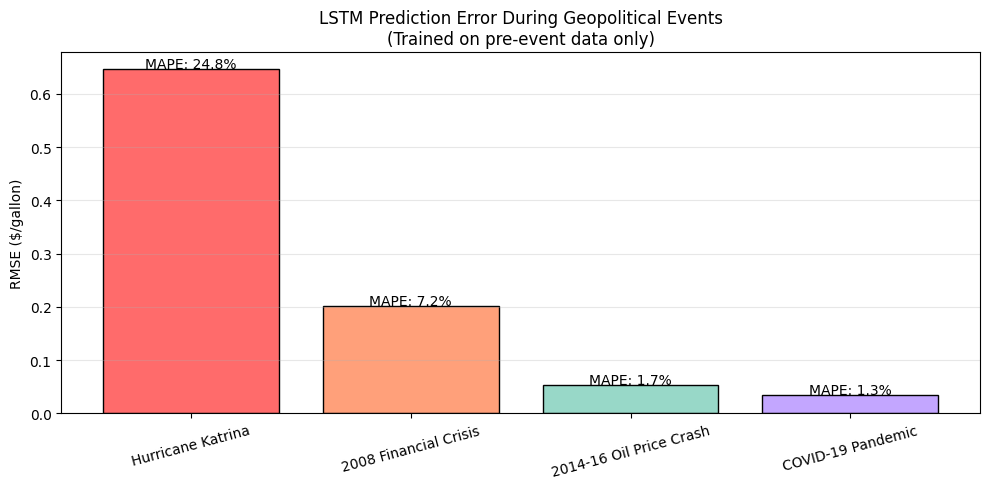

In [21]:
# Bar chart: LSTM RMSE by event
if len(event_lstm_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    colors_list = [event_colors.get(e, '#999999') for e in event_lstm_df['Event']]
    bars = ax.bar(event_lstm_df['Event'], event_lstm_df['RMSE'], color=colors_list, edgecolor='black')

    for bar, mape in zip(bars, event_lstm_df['MAPE (%)']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'MAPE: {mape:.1f}%', ha='center', fontsize=10)

    ax.set_ylabel('RMSE ($/gallon)')
    ax.set_title('LSTM Prediction Error During Geopolitical Events\n(Trained on pre-event data only)')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("No event results to plot.")

---

## Part 3: Concept Drift Analysis

Evaluate how well an LSTM trained on historical data generalizes to future unseen periods.

- **No-retrain**: Train on 1995-2021, test on 2022-2026
- **Retrained**: Train on 1995-2024, test on 2025-2026

In [22]:
# Load original national CSV (1995-2021)
# This CSV has columns: Date, A1, A2, A3, R1, R2, R3, M1, M2, M3, P1, P2, P3, D1
# We use A1 (All Grades, All Formulations) as our target price
df_orig = pd.read_csv('PET_PRI_GND_DCUS_NUS_W.csv')
df_orig['Date'] = pd.to_datetime(df_orig['Date'], format='%m/%d/%Y')
df_orig = df_orig[['Date', 'A1']].rename(columns={'A1': 'Price'})
df_orig['Price'] = pd.to_numeric(df_orig['Price'], errors='coerce')
df_orig = df_orig.dropna(subset=['Price']).sort_values('Date').reset_index(drop=True)
print(f'Original national data: {len(df_orig)} rows, {df_orig["Date"].min().date()} to {df_orig["Date"].max().date()}')

# Load updated national XLS (through 2026)
df_updated = load_xls_data('national_allgrades_updated.xls')
print(f'Updated national data: {len(df_updated)} rows, {df_updated["Date"].min().date()} to {df_updated["Date"].max().date()}')

Original national data: 1361 rows, 1995-01-02 to 2021-01-25
Updated national data: 1723 rows, 1993-04-05 to 2026-04-06


In [23]:
# Merge into full 1995-2026 dataset
# Use original for dates up to its max, then append new dates from updated
orig_max_date = df_orig['Date'].max()
df_new = df_updated[df_updated['Date'] > orig_max_date]
df_full = pd.concat([df_orig, df_new], ignore_index=True)
df_full = df_full.sort_values('Date').reset_index(drop=True)
print(f'Full merged data: {len(df_full)} rows, {df_full["Date"].min().date()} to {df_full["Date"].max().date()}')

Full merged data: 1632 rows, 1995-01-02 to 2026-04-06


In [24]:
# Feature engineering on full dataset
df_full_feat = add_features_single(df_full)
df_full_feat = create_target(df_full_feat)
df_full_feat = df_full_feat.dropna().reset_index(drop=True)

feature_cols = [c for c in df_full_feat.columns if c not in ['Date', 'Price', 'target']]
print(f'Features: {len(feature_cols)}')
print(f'Total samples after feature engineering: {len(df_full_feat)}')

Features: 21
Total samples after feature engineering: 1619


### No-Retrain Test: Train on 1995-2021, Test on 2022-2026

In [25]:
# Split by date: train on pre-2022, test on 2022+
cutoff_2021 = pd.Timestamp('2021-12-31')
df_train_pre2022 = df_full_feat[df_full_feat['Date'] <= cutoff_2021].copy()
df_test_post2021 = df_full_feat[df_full_feat['Date'] > cutoff_2021].copy()

print(f'Train (pre-2022): {len(df_train_pre2022)} rows')
print(f'Test (2022-2026): {len(df_test_post2021)} rows')

# Use last 15% of training data as validation
n_train = len(df_train_pre2022)
val_split = int(n_train * 0.85)
df_train_nr = df_train_pre2022.iloc[:val_split]
df_val_nr = df_train_pre2022.iloc[val_split:]

print(f'Train split: {len(df_train_nr)}, Val split: {len(df_val_nr)}')

Train (pre-2022): 1397 rows
Test (2022-2026): 222 rows
Train split: 1187, Val split: 210


In [26]:
# Prepare data
train_X_nr = df_train_nr[feature_cols].values
train_y_nr = df_train_nr['target'].values
val_X_nr = df_val_nr[feature_cols].values
val_y_nr = df_val_nr['target'].values
test_X_nr = df_test_post2021[feature_cols].values
test_y_nr = df_test_post2021['target'].values

train_loader_nr, val_loader_nr, test_loader_nr, scaler_nr, test_y_seq_nr = prepare_seq_data_single(
    train_X_nr, train_y_nr, val_X_nr, val_y_nr, test_X_nr, test_y_nr,
    seq_len=SEQ_LEN, batch_size=BATCH_SIZE
)

# Train model
torch.manual_seed(SEED)
n_features = train_X_nr.shape[1]
model_nr = LSTMModel(
    input_size=n_features,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

print('Training LSTM (no-retrain, 1995-2021)...')
model_nr, train_losses_nr, val_losses_nr = train_seq_model(
    model_nr, train_loader_nr, val_loader_nr,
    epochs=EPOCHS, lr=LR, patience=PATIENCE, device=device
)

# Evaluate
preds_nr = predict_seq_model(model_nr, test_loader_nr, device=device)
metrics_nr = evaluate_model(test_y_seq_nr, preds_nr)
print(f'\nNo-Retrain Test Metrics (2022-2026): {metrics_nr}')

Training LSTM (no-retrain, 1995-2021)...
Epoch 20/200 - Train Loss: 0.034310 - Val Loss: 0.008211
Epoch 40/200 - Train Loss: 0.026909 - Val Loss: 0.001945
Epoch 60/200 - Train Loss: 0.023179 - Val Loss: 0.002355
Epoch 80/200 - Train Loss: 0.022632 - Val Loss: 0.001574
Epoch 100/200 - Train Loss: 0.021606 - Val Loss: 0.001494
Early stopping at epoch 111

No-Retrain Test Metrics (2022-2026): {'RMSE': np.float64(0.1124), 'MAE': np.float64(0.0692), 'MAPE': np.float64(1.7898)}


### Retrained Test: Train on 1995-2024, Test on 2025-2026

In [27]:
# Split by date: train on pre-2025, test on 2025+
cutoff_2024 = pd.Timestamp('2024-12-31')
df_train_pre2025 = df_full_feat[df_full_feat['Date'] <= cutoff_2024].copy()
df_test_post2024 = df_full_feat[df_full_feat['Date'] > cutoff_2024].copy()

print(f'Train (pre-2025): {len(df_train_pre2025)} rows')
print(f'Test (2025-2026): {len(df_test_post2024)} rows')

# Use last 15% of training data as validation
n_train_rt = len(df_train_pre2025)
val_split_rt = int(n_train_rt * 0.85)
df_train_rt = df_train_pre2025.iloc[:val_split_rt]
df_val_rt = df_train_pre2025.iloc[val_split_rt:]

print(f'Train split: {len(df_train_rt)}, Val split: {len(df_val_rt)}')

Train (pre-2025): 1554 rows
Test (2025-2026): 65 rows
Train split: 1320, Val split: 234


In [28]:
# Prepare data
train_X_rt = df_train_rt[feature_cols].values
train_y_rt = df_train_rt['target'].values
val_X_rt = df_val_rt[feature_cols].values
val_y_rt = df_val_rt['target'].values
test_X_rt = df_test_post2024[feature_cols].values
test_y_rt = df_test_post2024['target'].values

train_loader_rt, val_loader_rt, test_loader_rt, scaler_rt, test_y_seq_rt = prepare_seq_data_single(
    train_X_rt, train_y_rt, val_X_rt, val_y_rt, test_X_rt, test_y_rt,
    seq_len=SEQ_LEN, batch_size=BATCH_SIZE
)

# Train model
torch.manual_seed(SEED)
model_rt = LSTMModel(
    input_size=n_features,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

print('Training LSTM (retrained, 1995-2024)...')
model_rt, train_losses_rt, val_losses_rt = train_seq_model(
    model_rt, train_loader_rt, val_loader_rt,
    epochs=EPOCHS, lr=LR, patience=PATIENCE, device=device
)

# Evaluate
preds_rt = predict_seq_model(model_rt, test_loader_rt, device=device)
metrics_rt = evaluate_model(test_y_seq_rt, preds_rt)
print(f'\nRetrained Test Metrics (2025-2026): {metrics_rt}')

Training LSTM (retrained, 1995-2024)...
Epoch 20/200 - Train Loss: 0.038275 - Val Loss: 0.022234
Epoch 40/200 - Train Loss: 0.027225 - Val Loss: 0.013233
Epoch 60/200 - Train Loss: 0.022973 - Val Loss: 0.012185
Epoch 80/200 - Train Loss: 0.023308 - Val Loss: 0.014304
Early stopping at epoch 84

Retrained Test Metrics (2025-2026): {'RMSE': np.float64(0.0945), 'MAE': np.float64(0.0562), 'MAPE': np.float64(1.6075)}


### Concept Drift Comparison

In [29]:
# Compare metrics
drift_results = {
    'no_retrain_2022_2026': metrics_nr,
    'retrained_2025_2026': metrics_rt
}

drift_df = pd.DataFrame(drift_results).T
drift_df.index.name = 'Scenario'
print('\nConcept Drift LSTM Comparison:')
print('=' * 60)
print(drift_df.to_string())

# Save results
save_results(drift_results, 'lstm_concept_drift_results.json')


Concept Drift LSTM Comparison:
                        RMSE     MAE    MAPE
Scenario                                    
no_retrain_2022_2026  0.1124  0.0692  1.7898
retrained_2025_2026   0.0945  0.0562  1.6075
Results saved to lstm_concept_drift_results.json


### Concept Drift Prediction Plots

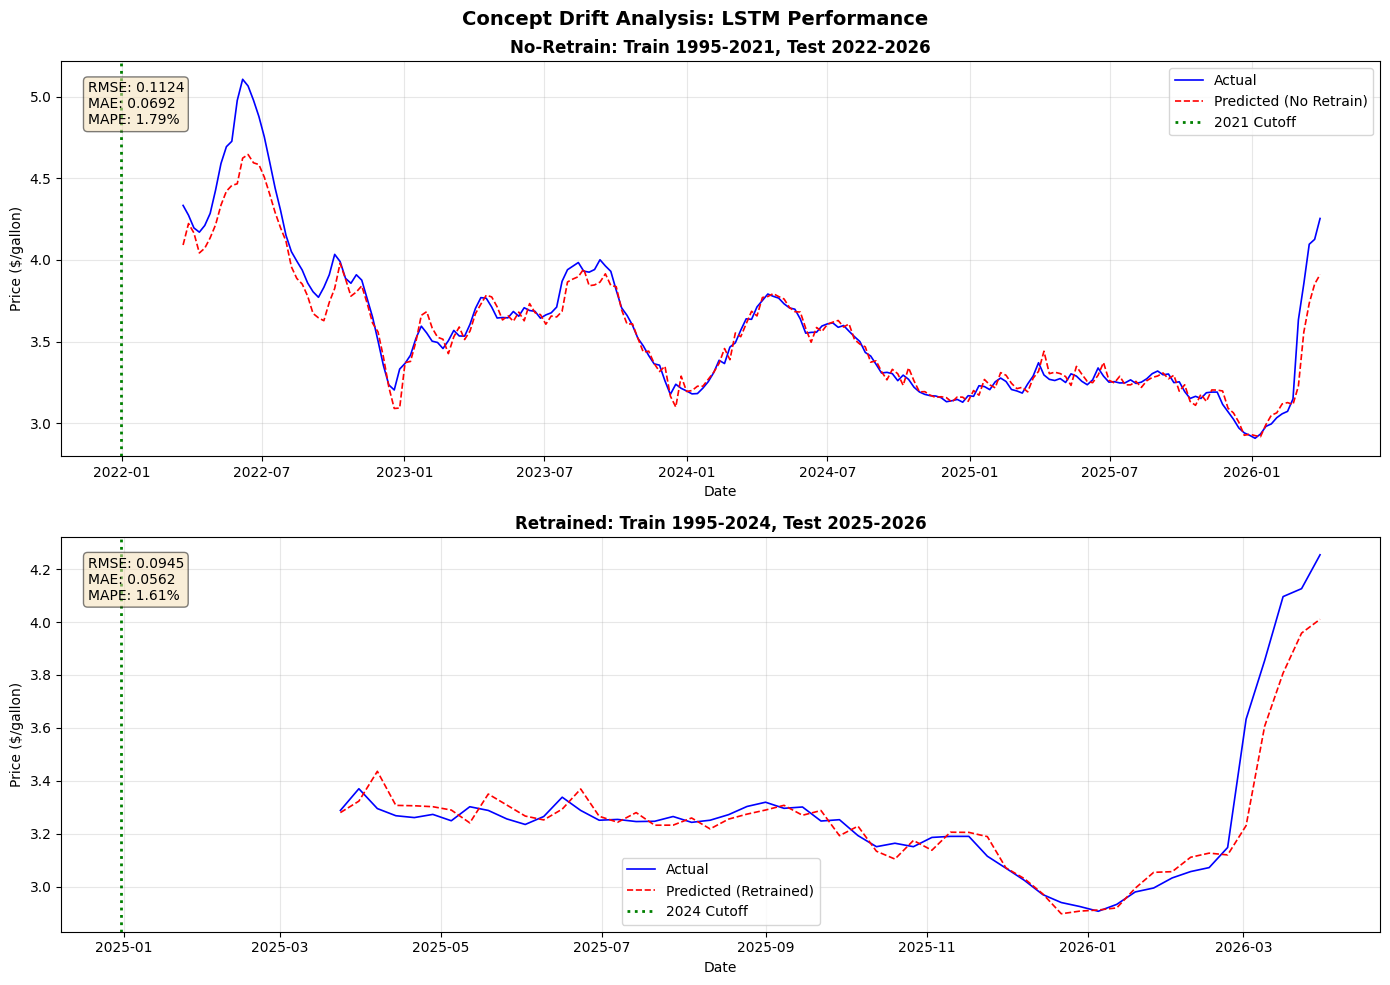

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: No-retrain (2022-2026)
ax1 = axes[0]
dates_nr = pd.to_datetime(df_test_post2021['Date'].values[SEQ_LEN - 1:])
ax1.plot(dates_nr, test_y_seq_nr, label='Actual', color='blue', linewidth=1.2)
ax1.plot(dates_nr, preds_nr, label='Predicted (No Retrain)', color='red',
         linewidth=1.2, linestyle='--')
ax1.axvline(x=cutoff_2021, color='green', linestyle=':', linewidth=2, label='2021 Cutoff')
ax1.set_title('No-Retrain: Train 1995-2021, Test 2022-2026', fontsize=12, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price ($/gallon)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.text(0.02, 0.95,
         f"RMSE: {metrics_nr['RMSE']:.4f}\nMAE: {metrics_nr['MAE']:.4f}\nMAPE: {metrics_nr['MAPE']:.2f}%",
         transform=ax1.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Retrained (2025-2026)
ax2 = axes[1]
dates_rt = pd.to_datetime(df_test_post2024['Date'].values[SEQ_LEN - 1:])
ax2.plot(dates_rt, test_y_seq_rt, label='Actual', color='blue', linewidth=1.2)
ax2.plot(dates_rt, preds_rt, label='Predicted (Retrained)', color='red',
         linewidth=1.2, linestyle='--')
ax2.axvline(x=cutoff_2024, color='green', linestyle=':', linewidth=2, label='2024 Cutoff')
ax2.set_title('Retrained: Train 1995-2024, Test 2025-2026', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price ($/gallon)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.text(0.02, 0.95,
         f"RMSE: {metrics_rt['RMSE']:.4f}\nMAE: {metrics_rt['MAE']:.4f}\nMAPE: {metrics_rt['MAPE']:.2f}%",
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Concept Drift Analysis: LSTM Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_concept_drift_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Download Results

In [31]:
# Zip all result JSONs into one file and download
import glob
import zipfile

result_files = sorted(glob.glob('lstm_*.json'))
print(f'Found {len(result_files)} result files:')
for f in result_files:
    print(f'  - {f}')

with zipfile.ZipFile('lstm_results.zip', 'w') as zf:
    for f in result_files:
        zf.write(f)

print(f'\nZipped into lstm_results.zip')
files.download('lstm_results.zip')
print('Download started — unzip into your local results/ folder')

Found 8 result files:
  - lstm_concept_drift_results.json
  - lstm_event_analysis.json
  - lstm_regional_comparison.json
  - lstm_regional_padd1_east_coast.json
  - lstm_regional_padd2_midwest.json
  - lstm_regional_padd3_gulf_coast.json
  - lstm_regional_padd4_rocky_mountain.json
  - lstm_regional_padd5_west_coast.json

Zipped into lstm_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started — unzip into your local results/ folder
